In [1]:
import demes
import numpy as np
import moments
import dpluspy

In [2]:
# Load data etc
null_params = "models/null.params.yaml"
null_graph = "best_fits/null.refitted.24_round1.yaml"
pulse_params = "models/pulse.params.yaml"
pulse_graph = "best_fits/pulse.refitted.46_round1.yaml"

data_file = "bootstrap_subset_stats.pkl"
pop_ids, bins, means, varcovs, bootreps = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=null_graph, num_reps=100)

u = 1.3e-8
pnames0, params0 = dpluspy.inference._load_params(null_graph, null_params)
model0 = dpluspy.inference.compute_bin_stats(
    null_graph, sampled_demes=pop_ids, u=u, bins=bins)

pnames1, params1 = dpluspy.inference._load_params(pulse_graph, pulse_params)
model1 = dpluspy.inference.compute_bin_stats(
    pulse_graph, sampled_demes=pop_ids, u=u, bins=bins)

ll0 = dpluspy.inference.composite_ll(model0, means, varcovs)
ll1 = dpluspy.inference.composite_ll(model1, means, varcovs)
D_naive = 2 * (ll1 - ll0)
# We act here as though pulse time is not on a parameter boundary
weights = (0, 0.5, 0.5)
p_naive = moments.Godambe.sum_chi2_ppf(D_naive, weights=weights)
print(f"D_naive = {D_naive:.3}")
print(f"p_naive = {p_naive:.3}")

D_naive = 6.46e+02
p_naive = 0.0


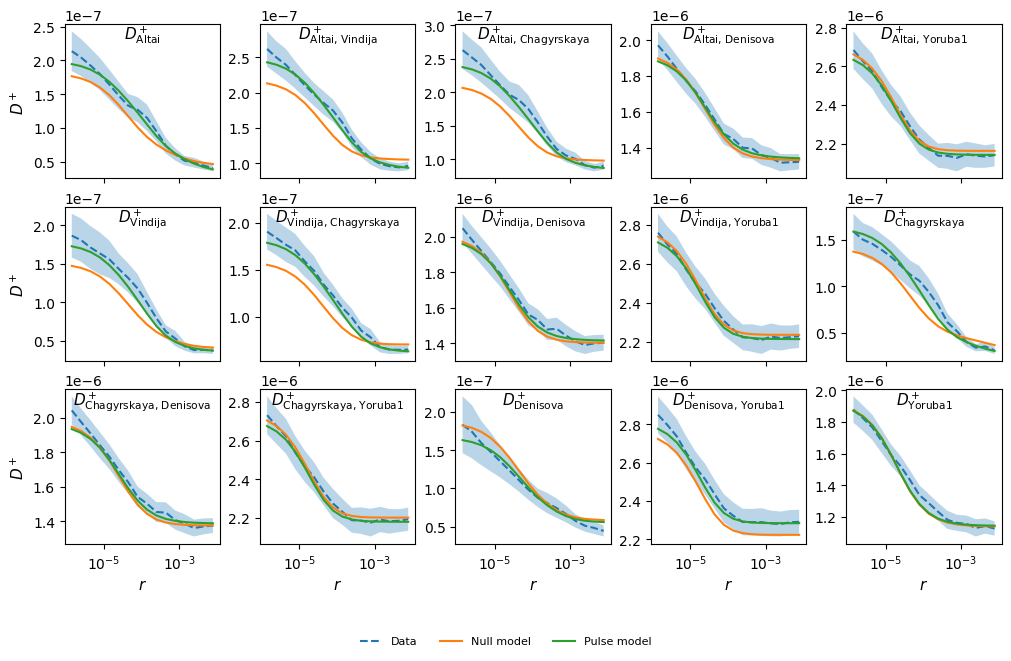

In [5]:
# Plot fits
dpluspy.plotting.plot_D_plus_curves(
    models=[model0, model1],
    means=means, varcovs=varcovs, bins=bins, pop_ids=pop_ids, 
    labels=["Data", "Null model", "Pulse model"],
    out="figures/fig_best_fits.pdf"
)

In [3]:
print("Pulse model MLE parameters")
for name, val in zip(pnames1, params1):
    print(f"{name}\t{val:.3}")

Pulse model MLE parameters
T_0	8.03e+05
T_ND	7.74e+05
T_A	1.3e+05
T_CV	8.72e+04
N_0	1.58e+04
N_Y	2.8e+04
N_ND	1.01e+03
N_N	2.98e+03
N_A	6.77e+02
N_C	3.23e+02
N_V	1.61e+03
m_AD	1.25e-05
m_AWN	2.48e-05
T_AMH_N	2.66e+05
p_AMH_N	0.0924


In [4]:
# Adjustment using model 0 MLE parameters
_, __, model1_args = dpluspy.uncerts.set_up_model_args(
    pulse_graph, pulse_params, bins=bins, pop_ids=pop_ids, u=u)

p_lrt = np.concatenate([params0, [params1[-2], 0]])
steps = np.array([params1[-2], params1[-1] ]) * 0.01
nested_idx = np.array([13, 14])
print("Nested parameters and steps:")
print(p_lrt[nested_idx])
print(steps)
print("\nAdjustment parameters")
for name, val in zip(pnames1, p_lrt):
    print(f"{name}\t{val:.3}")

adj = dpluspy.uncerts.LRT_adjust(
    p_lrt, 
    model1_args, 
    means, 
    varcovs, 
    bootreps, 
    nested_idx, 
    steps=steps,
    verbose=0
)

# Compute the adjusted LR test statistic
D_adj = adj * D_naive
p_adj = moments.Godambe.sum_chi2_ppf(D_adj, weights=weights)

print(f"\nadj = {adj:.3}")
print(f"D_adj = {D_adj:.3}")
print(f"p = {p_adj:.3}")

Nested parameters and steps:
[266128.59655827      0.        ]
[2.66128597e+03 9.23732271e-04]

Adjustment parameters
T_0	7.68e+05
T_ND	7.21e+05
T_A	1.48e+05
T_CV	8.49e+04
N_0	1.6e+04
N_Y	2.8e+04
N_ND	2.1e+03
N_N	4.25e+03
N_A	1.6e+03
N_C	2.38e+02
N_V	1.5e+03
m_AD	5.32e-06
m_AWN	1e-08
T_AMH_N	2.66e+05
p_AMH_N	0.0

adj = -0.223
D_adj = -1.44e+02
p = 1.0


In [5]:
# Compute adjustment using model 1 fitted parameters
_, __, model1_args = dpluspy.uncerts.set_up_model_args(
    pulse_graph, pulse_params, bins=bins, pop_ids=pop_ids, u=u)

p_lrt = params1
steps = p_lrt[-2:] * 0.01
nested_idx = np.array([13, 14])
print("Nested parameters and steps:")
print(p_lrt[nested_idx])
print(steps)
print("\nAdjustment parameters")
for name, val in zip(pnames1, p_lrt):
    print(f"{name}\t{val:.3}")

adj = dpluspy.uncerts.LRT_adjust(
    p_lrt, 
    model1_args, 
    means, 
    varcovs, 
    bootreps, 
    nested_idx, 
    steps=steps,
    verbose=0
)

# Compute the adjusted LR test statistic
D_adj = adj * D_naive
p_adj = moments.Godambe.sum_chi2_ppf(D_adj, weights=weights)

print(f"\nadj = {adj:.3}")
print(f"D_adj = {D_adj:.3}")
print(f"p = {p_adj:.3}")

Nested parameters and steps:
[2.66128597e+05 9.23732271e-02]
[2.66128597e+03 9.23732271e-04]

Adjustment parameters
T_0	8.03e+05
T_ND	7.74e+05
T_A	1.3e+05
T_CV	8.72e+04
N_0	1.58e+04
N_Y	2.8e+04
N_ND	1.01e+03
N_N	2.98e+03
N_A	6.77e+02
N_C	3.23e+02
N_V	1.61e+03
m_AD	1.25e-05
m_AWN	2.48e-05
T_AMH_N	2.66e+05
p_AMH_N	0.0924

adj = 0.107
D_adj = 69.1
p = 5.55e-16
